In [1]:
import pypsa
import gurobipy as gp
import re

In [3]:
import pandas as pd
YEAR = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{YEAR}.csv"
costs = pd.read_csv(url, index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs = costs.value.unstack().fillna({"discount rate": 0.07, "lifetime": 20, "FOM": 0})

In [6]:
def annuity(r: float, n: int) -> float:
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

a = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

costs["capital_cost"] = (a + costs["FOM"] / 100) * costs["investment"]



In [9]:
costs.investment

technology
Alkaline electrolyzer large size     4.290306e+05
Alkaline electrolyzer medium size    5.060332e+05
Alkaline electrolyzer small size     5.829220e+05
Ammonia cracker                      1.123945e+06
BEV Bus city                         2.224856e+05
                                         ...     
uranium                                       NaN
waste CHP                            8.582594e+06
waste CHP CC                         8.582594e+06
water tank charger                            NaN
water tank discharger                         NaN
Name: investment, Length: 294, dtype: float64

In [7]:
costs["capital_cost"]

technology
Alkaline electrolyzer large size      44194.072656
Alkaline electrolyzer medium size     59404.717871
Alkaline electrolyzer small size      68430.919060
Ammonia cracker                      144775.985816
BEV Bus city                          28012.052635
                                         ...      
uranium                                        NaN
waste CHP                            938596.962679
waste CHP CC                         938596.962679
water tank charger                             NaN
water tank discharger                          NaN
Name: capital_cost, Length: 294, dtype: float64

In [2]:
import pypsa
# ...existing code...
# network = pypsa.Network("../networks/isp24_v1.nc")

# network = pypsa.Network("../networks/isp24_v3_12h.nc")
network = pypsa.Network("../networks/isp24_v6_6h_transmission_losses.nc")
# network = pypsa.Network("../networks/isp24_v6_6h_no_lossess.nc")

# network = pypsa.Network("../networks/isp24_v5_12h_solved.nc")
# ...existing code...

INFO:pypsa.network.io:Imported network '12h' has buses, carriers, generators, links, loads, storage_units, transformers


In [18]:
testn.optimize.create_model()

Index(['test no bounds'], dtype='object', name='Link')
Index(['bus0', 'bus1'], dtype='object', name='Bus')


Linopy LP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Bus-nodal_balance (Bus, snapshot)

Status:
-------
initialized

In [ ]:
testn.model.add_constraints(

Linopy LP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Bus-nodal_balance (Bus, snapshot)

Status:
-------
initialized

In [21]:
augmentations = {"aug1": {"cost": 100, "capacity": 200}}
years = [100]

x = testn.model.add_variables(
        coords={"aug": list(augmentations.keys()), "year": years},
        binary=True,
        name="augment_option"
    )

CoordinateValidationError: coordinate aug has dimensions ('aug',), but these are not a subset of the DataArray dimensions ()

In [11]:
network.links.index

Index(['CQ-NQ', 'CQ-GG', 'SQ-CQ', 'NNSW-SQ QNI', 'NNSW-SQ Terranora',
       'CNSW–NNSW QNI', 'CNSW­–SNW North', 'CNSW–SNW South', 'SNSW–CNSW VNI',
       'VIC–SNSW VNI', 'VIC-SESA Heywood', 'SESA-CSA', 'VIC-CSA Murraylink',
       'TAS-VIC Basslink'],
      dtype='object', name='Link')

In [4]:
network.optimize.create_model()
network.model.variables

linopy.model.Variables
----------------------
 * Generator-p_nom (Generator-ext)
 * StorageUnit-p_nom (StorageUnit-ext)
 * Generator-p (snapshot, period, timestep, Generator)
 * Transformer-s (snapshot, period, timestep, Transformer)
 * Link-p (snapshot, period, timestep, Link)
 * StorageUnit-p_dispatch (snapshot, period, timestep, StorageUnit)
 * StorageUnit-p_store (snapshot, period, timestep, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, period, timestep, StorageUnit)

In [6]:
network.model.variables['Generator-p_nom']

Variable (Generator-ext: 171)
-----------------------------
[OCGT_(small_GT)_NQ]: Generator-p_nom[OCGT_(small_GT)_NQ] ∈ [-inf, inf]
[OCGT_(small_GT)_CQ]: Generator-p_nom[OCGT_(small_GT)_CQ] ∈ [-inf, inf]
[OCGT_(small_GT)_GG]: Generator-p_nom[OCGT_(small_GT)_GG] ∈ [-inf, inf]
[OCGT_(small_GT)_SQ]: Generator-p_nom[OCGT_(small_GT)_SQ] ∈ [-inf, inf]
[OCGT_(small_GT)_NNSW]: Generator-p_nom[OCGT_(small_GT)_NNSW] ∈ [-inf, inf]
[OCGT_(small_GT)_CNSW]: Generator-p_nom[OCGT_(small_GT)_CNSW] ∈ [-inf, inf]
[OCGT_(small_GT)_SNW]: Generator-p_nom[OCGT_(small_GT)_SNW] ∈ [-inf, inf]
		...
[Wind_-_offshore_(floating)_SNW_Hunter_Coast]: Generator-p_nom[Wind_-_offshore_(floating)_SNW_Hunter_Coast] ∈ [-inf, inf]
[Wind_-_offshore_(floating)_SNW_Illawarra_Coast]: Generator-p_nom[Wind_-_offshore_(floating)_SNW_Illawarra_Coast] ∈ [-inf, inf]
[Wind_-_offshore_(floating)_VIC_Gippsland_Coast]: Generator-p_nom[Wind_-_offshore_(floating)_VIC_Gippsland_Coast] ∈ [-inf, inf]
[Wind_-_offshore_(floating)_VIC_Portland_C

In [5]:
network.model.variables['Generator-p']

Variable (snapshot (period, timestep): 11688, Generator: 658)
-------------------------------------------------------------
[(2024, 2024-07-01 00:00:00), Bayswater (BW01)]: Generator-p[(2024, 2024-07-01 00:00:00), Bayswater (BW01)] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), Bayswater (BW02)]: Generator-p[(2024, 2024-07-01 00:00:00), Bayswater (BW02)] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), Bayswater (BW03)]: Generator-p[(2024, 2024-07-01 00:00:00), Bayswater (BW03)] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), Bayswater (BW04)]: Generator-p[(2024, 2024-07-01 00:00:00), Bayswater (BW04)] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), Callide B (CALL_B_1)]: Generator-p[(2024, 2024-07-01 00:00:00), Callide B (CALL_B_1)] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), Callide B (CALL_B_2)]: Generator-p[(2024, 2024-07-01 00:00:00), Callide B (CALL_B_2)] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), Callide C (CPP_3)]: Generator-p[(2024, 2024-07-01 00:00:00), Callide C (CPP_3)] ∈ [-inf, inf]
		..

In [ ]:
from collections import defaultdict as dd

rez_map = dd(dict)

df= = pd.read_csv("map.csv")

for _,row in df.iterrows():

    rez_map[row['Option Name']][row['REZ Name']] = row['Additional Hosting Capacity']

rez_map['CQ-NQ Option 1']['Q3']=1100
rez_map['CQ-NQ Option 2']['Q3']=3000
rez_map['CQ-NQ Option 2']['Q2']=800



In [136]:
rez_map

defaultdict(dict, {'CQ-NQ Option 1': {'Q3': 1100}})

In [16]:
testn  = pypsa.Network()
testn.add("Bus","bus0",v_nom=100)
testn.add("Bus","bus1",v_nom=100)
testn.add("Generator","bus1",bus="bus1",p_nom=100,marginal_cost=109)
testn.add("Load","bus1",bus="bus1",p_nom=100)
testn.add("Link",name="test no bounds",bus0="bus0",bus1="bus1",type="AC",p_nom=1e6,p_min_pu=-1)


Index(['test no bounds'], dtype='object')

In [33]:
testn.model.constraints["con0"]

Constraint `con0` [snapshot: 1, Link: 1]:
-----------------------------------------
[now, test no bounds]: +1 Link-p[now, test no bounds] - 150 xaug ≤ 120.0

In [ ]:
testn.model.add_constraints()

In [29]:
testn.model.remove_constraints("Link-fix-p-upper")

In [ ]:
network.model

Linopy LP model

Variables:
----------
 * Generator-p_nom (Generator-ext)
 * StorageUnit-p_nom (StorageUnit-ext)
 * Generator-p (snapshot, period, timestep, Generator)
 * Transformer-s (snapshot, period, timestep, Transformer)
 * Link-p (snapshot, period, timestep, Link)
 * StorageUnit-p_dispatch (snapshot, period, timestep, StorageUnit)
 * StorageUnit-p_store (snapshot, period, timestep, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, period, timestep, StorageUnit)

Constraints:
------------
 * Generator-ext-p_nom-lower (Generator-ext)
 * Generator-ext-p_nom-upper (Generator-ext)
 * StorageUnit-ext-p_nom-lower (StorageUnit-ext)
 * StorageUnit-ext-p_nom-upper (StorageUnit-ext)
 * Generator-fix-p-lower (snapshot, period, timestep, Generator-fix)
 * Generator-fix-p-upper (snapshot, period, timestep, Generator-fix)
 * Generator-ext-p-lower (snapshot, period, timestep, Generator-ext)
 * Generator-ext-p-upper (snapshot, period, timestep, Generator-ext)
 * Transformer-fix-s-lower (sna

In [119]:
testn.optimize.create_model()

Index(['bus1'], dtype='object', name='Generator')
Index(['bus1'], dtype='object', name='Load')
Index(['test no bounds'], dtype='object', name='Link')


Index(['bus0', 'bus1'], dtype='object', name='Bus')


Linopy LP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Bus-nodal_balance (Bus, snapshot)

Status:
-------
initialized

In [120]:
print(testn.model.constraints["Link-fix-p-upper"])
testn.model.constraints["Link-fix-p-lower"]

Constraint `Link-fix-p-upper` [snapshot: 1, Link-fix: 1]:
---------------------------------------------------------
[now, test no bounds]: +1 Link-p[now, test no bounds] ≤ 1000000.0


Constraint `Link-fix-p-lower` [snapshot: 1, Link-fix: 1]:
---------------------------------------------------------
[now, test no bounds]: +1 Link-p[now, test no bounds] ≥ -1000000.0

In [38]:
# x = testn.model.add_variables(name="xaug",binary=True)
testx = testn.model.variables['Link-p'].loc[:]
print(testx)
# testn.model.add_constraints( testx <= 150*x + 120, name = "hi")
testn.model.add_constraints(-testx <= 100*x + 100, name = "lesgo")


Variable (snapshot: 1, Link: 1)
-------------------------------
[now, test no bounds]: Link-p[now, test no bounds] ∈ [-inf, inf]


Constraint `lesgo` [snapshot: 1, Link: 1]:
------------------------------------------
[now, test no bounds]: -1 Link-p[now, test no bounds] - 100 xaug ≤ 100.0

In [43]:
network.global_constraints

,type,investment_period,carrier_attribute,sense,constant,mu
GlobalConstraint,,,,,,
CO2Limit,primary_energy,2025.0,co2_emissions,<=,150.0,0.0


In [ ]:
network.model

In [41]:
network.add(
            "GlobalConstraint",
            "CO2Limit",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=150,
            investment_period=2025)

Index(['CO2Limit'], dtype='object')

In [114]:
import linopy as lp

m = lp.Model()

# Variables
line_flow = m.add_variables(lower=-1e4, upper=1e4, name="line_flow")
option = m.add_variables( binary=True, name="option")  # binary

# Constraint 1: -line_flow <= 120*option + 120
m.add_constraints(-line_flow <= 120*option + 120)

# Constraint 2: line_flow <= 100*option + 100
m.add_constraints(line_flow <= 100*option + 100)


Constraint `con1`
-----------------
+1 line_flow - 100 option ≤ 100.0

In [122]:
testn.model.constraints["Link-fix-p-upper"]

Constraint `Link-fix-p-upper` [snapshot: 1, Link-fix: 1]:
---------------------------------------------------------
[now, test no bounds]: +1 Link-p[now, test no bounds] ≤ 1000000.0

In [107]:
# testn.model.variables["Link-p"]
testn.model.constraints["Link-fix-p-lower"]


Constraint `Link-fix-p-lower` [snapshot: 1, Link-fix: 1]:
---------------------------------------------------------
[now, test no bounds]: +1 Link-p[now, test no bounds] ≥ -1000.0

In [123]:
testn.model.constraints

linopy.model.Constraints
------------------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * con0 (snapshot, Link)
 * con1 (snapshot, Link)

In [ ]:
network.model.constraints['Link-fix-p-upper']


In [16]:
network.model.constraints['Link-fix-p-lower']

Constraint `Link-fix-p-lower` [snapshot (period, timestep): 11688, Link-fix: 14]:
---------------------------------------------------------------------------------
[(2024, 2024-07-01 00:00:00), CQ-NQ]: +1 Link-p[(2024, 2024-07-01 00:00:00), CQ-NQ]                           ≥ -1400.0
[(2024, 2024-07-01 00:00:00), CQ-GG]: +1 Link-p[(2024, 2024-07-01 00:00:00), CQ-GG]                           ≥ -1100.0
[(2024, 2024-07-01 00:00:00), SQ-CQ]: +1 Link-p[(2024, 2024-07-01 00:00:00), SQ-CQ]                           ≥ -2100.0
[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI]: +1 Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI]               ≥ -1205.0
[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora]: +1 Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora]   ≥ -200.0
[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI]: +1 Link-p[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI]           ≥ -1025.0
[(2024, 2024-07-01 00:00:00), CNSW­–SNW North]: +1 Link-p[(2024, 2024-07-01 00:00:00), CNSW­–SNW North]       ≥ -4730

In [128]:
dev2026 = network.model.variables['Link-p'].loc[(2026,):]

In [ ]:
network.model.add_objective()
network.model.add_variables()

In [133]:
aug2026 = network.model.add_variables(name="aug2026",binary=True)

In [134]:
network.model.add_constraints(dev2026 <= 1400+2500*aug2026)


Constraint `con6` [snapshot (period, timestep): 9492, Link: 14]:
----------------------------------------------------------------
[(2026, 2026-01-01 00:00:00), CQ-NQ]: +1 Link-p[(2026, 2026-01-01 00:00:00), CQ-NQ] - 2500 aug2026                           ≤ 1400.0
[(2026, 2026-01-01 00:00:00), CQ-GG]: +1 Link-p[(2026, 2026-01-01 00:00:00), CQ-GG] - 2500 aug2026                           ≤ 1400.0
[(2026, 2026-01-01 00:00:00), SQ-CQ]: +1 Link-p[(2026, 2026-01-01 00:00:00), SQ-CQ] - 2500 aug2026                           ≤ 1400.0
[(2026, 2026-01-01 00:00:00), NNSW-SQ QNI]: +1 Link-p[(2026, 2026-01-01 00:00:00), NNSW-SQ QNI] - 2500 aug2026               ≤ 1400.0
[(2026, 2026-01-01 00:00:00), NNSW-SQ Terranora]: +1 Link-p[(2026, 2026-01-01 00:00:00), NNSW-SQ Terranora] - 2500 aug2026   ≤ 1400.0
[(2026, 2026-01-01 00:00:00), CNSW–NNSW QNI]: +1 Link-p[(2026, 2026-01-01 00:00:00), CNSW–NNSW QNI] - 2500 aug2026           ≤ 1400.0
[(2026, 2026-01-01 00:00:00), CNSW­–SNW North]: +1 Link-p[(2026, 2

In [ ]:
test = network.model.variables['Link-p'].loc[:]
# testaug = network.model.variables['aug'].loc[:]

network.model.add_constraints(0 <= test <= 1400*x)

Constraint `con5` [snapshot (period, timestep): 11688, Link: 14]:
-----------------------------------------------------------------
[(2024, 2024-07-01 00:00:00), CQ-NQ]: +1 Link-p[(2024, 2024-07-01 00:00:00), CQ-NQ] - 1400 augx_2025                           ≤ -0.0
[(2024, 2024-07-01 00:00:00), CQ-GG]: +1 Link-p[(2024, 2024-07-01 00:00:00), CQ-GG] - 1400 augx_2025                           ≤ -0.0
[(2024, 2024-07-01 00:00:00), SQ-CQ]: +1 Link-p[(2024, 2024-07-01 00:00:00), SQ-CQ] - 1400 augx_2025                           ≤ -0.0
[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI]: +1 Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI] - 1400 augx_2025               ≤ -0.0
[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora]: +1 Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora] - 1400 augx_2025   ≤ -0.0
[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI]: +1 Link-p[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI] - 1400 augx_2025           ≤ -0.0
[(2024, 2024-07-01 00:00:00), CNSW­–SNW North]: +1 Link-p[(2024,

In [ ]:
network.

In [21]:
network.model.constraints['Link-fix-p-upper'] #.loc[(2024, '2024-07-01 00:00:00'), 'CQ-NQ'] = 1401

Constraint `Link-fix-p-upper` [snapshot (period, timestep): 11688, Link-fix: 14]:
---------------------------------------------------------------------------------
[(2024, 2024-07-01 00:00:00), CQ-NQ]: +1 Link-p[(2024, 2024-07-01 00:00:00), CQ-NQ]                           ≤ 1400.0
[(2024, 2024-07-01 00:00:00), CQ-GG]: +1 Link-p[(2024, 2024-07-01 00:00:00), CQ-GG]                           ≤ 1050.0
[(2024, 2024-07-01 00:00:00), SQ-CQ]: +1 Link-p[(2024, 2024-07-01 00:00:00), SQ-CQ]                           ≤ 1100.0
[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI]: +1 Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI]               ≤ 745.0
[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora]: +1 Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora]   ≤ 50.0
[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI]: +1 Link-p[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI]           ≤ 910.0
[(2024, 2024-07-01 00:00:00), CNSW­–SNW North]: +1 Link-p[(2024, 2024-07-01 00:00:00), CNSW­–SNW North]       ≤ 4730.0
		...
[

In [14]:
network.model.variables['Link-p']

Variable (snapshot (period, timestep): 11688, Link: 14)
-------------------------------------------------------
[(2024, 2024-07-01 00:00:00), CQ-NQ]: Link-p[(2024, 2024-07-01 00:00:00), CQ-NQ] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), CQ-GG]: Link-p[(2024, 2024-07-01 00:00:00), CQ-GG] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), SQ-CQ]: Link-p[(2024, 2024-07-01 00:00:00), SQ-CQ] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI]: Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ QNI] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora]: Link-p[(2024, 2024-07-01 00:00:00), NNSW-SQ Terranora] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI]: Link-p[(2024, 2024-07-01 00:00:00), CNSW–NNSW QNI] ∈ [-inf, inf]
[(2024, 2024-07-01 00:00:00), CNSW­–SNW North]: Link-p[(2024, 2024-07-01 00:00:00), CNSW­–SNW North] ∈ [-inf, inf]
		...
[(2032, 2032-06-30 18:00:00), CNSW–SNW South]: Link-p[(2032, 2032-06-30 18:00:00), CNSW–SNW South] ∈ [-inf, inf]
[(2032, 2032-06-30 18:00:00), SN

In [13]:
network.optimize.create_model()

network.model.variables

linopy.model.Variables
----------------------
 * Generator-p_nom (Generator-ext)
 * StorageUnit-p_nom (StorageUnit-ext)
 * Generator-p (snapshot, period, timestep, Generator)
 * Transformer-s (snapshot, period, timestep, Transformer)
 * Link-p (snapshot, period, timestep, Link)
 * StorageUnit-p_dispatch (snapshot, period, timestep, StorageUnit)
 * StorageUnit-p_store (snapshot, period, timestep, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, period, timestep, StorageUnit)

INFO:pypsa.network.io:Imported network '12h' has buses, carriers, generators, links, loads, storage_units, transformers


<Axes: >

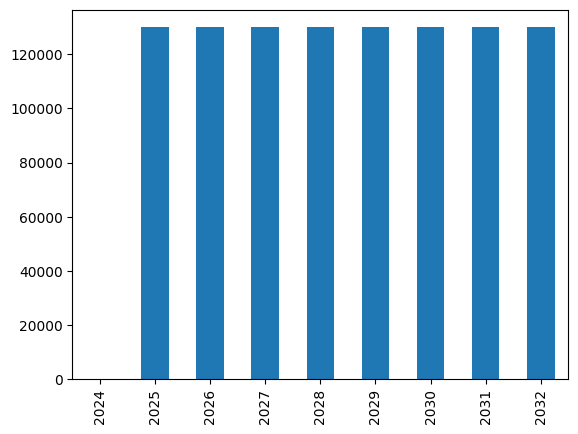

In [9]:
network = pypsa.Network("../networks/isp24_v6_6h_transmission_losses.nc")
network.statistics.optimal_capacity().div(1e3).sum().plot(kind="bar")


<Axes: >

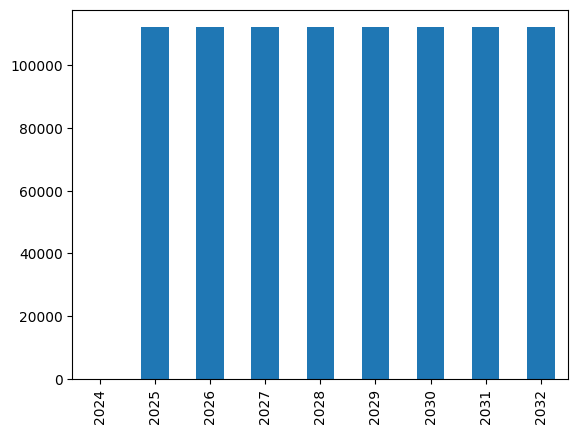

In [ ]:
network = pypsa.Network("../networks/isp24_v6_6h_no_lossess.nc")
network.statistics.optimal_capacity().div(1e3).sum().plot(kind="bar")

In [25]:
model = network.optimize.create_model()
network.optimize.solve_model(
    solver_name="gurobi",
    solver_options={"LogFile": "../gurobi.log"}
)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - LogFile: ../gurobi.log
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:01<00:00,  5.67it/s]
INFO:linopy.io: Writing time: 9.29s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2703023


INFO:gurobipy:Set parameter LicenseID to value 2703023


...

Solved in 2174 iterations and 1.67 seconds (2.93 work units)


INFO:gurobipy:Solved in 2174 iterations and 1.67 seconds (2.93 work units)


Optimal objective  1.640559703e+07


INFO:gurobipy:Optimal objective  1.640559703e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1187199 primals, 2628219 duals
Objective: 1.64e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [38]:
network.investment_periods

Index([2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035,
       2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
       2048, 2049, 2050, 2051, 2052],
      dtype='int32', name='period')

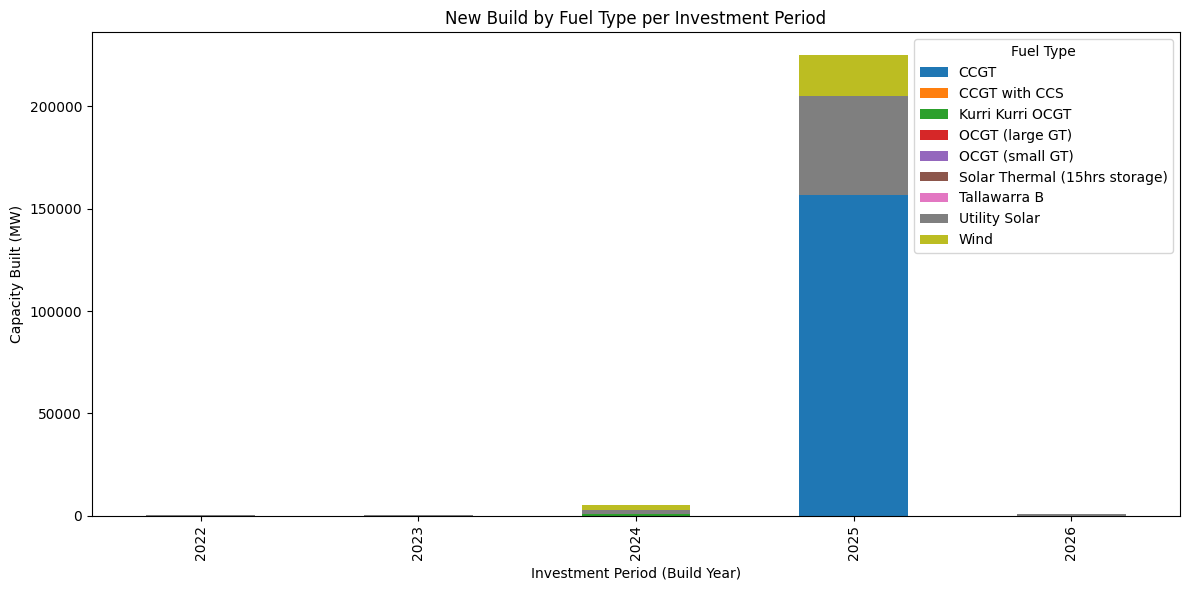

In [37]:
import matplotlib.pyplot as plt

def plot_build_by_fuel(network):
    """
    Plots the total new build (p_nom_opt) for each fuel type per investment period.
    Assumes the network is solved and has generators with 'build_year' and 'carrier' attributes.
    """
    # Get generator DataFrame
    gens = network.generators

    # Only consider generators that are extendable (i.e., new builds)
    if "p_nom_opt" not in gens.columns:
        print("Network not solved or p_nom_opt missing.")
        return

    # Get build_year and carrier for each generator
    build_years = gens["build_year"] if "build_year" in gens.columns else gens.index.map(lambda x: network.generators.at[x, "build_year"])
    carriers = gens["carrier"]

    # Group by (build_year, carrier) and sum p_nom_opt
    build_df = gens.groupby([build_years, carriers])["p_nom_opt"].sum().unstack(fill_value=0)

    # Plot
    build_df.plot(kind="bar", stacked=True, figsize=(12,6))
    plt.xlabel("Investment Period (Build Year)")
    plt.ylabel("Capacity Built (MW)")
    plt.title("New Build by Fuel Type per Investment Period")
    plt.legend(title="Fuel Type")
    plt.tight_layout()
    plt.show()

plot_build_by_fuel(network)

In [46]:
network.statistics

In [45]:
network.statistics.optimal_capacity()

2024          2025  \
component   carrier                                                 
Generator   CCGT                                NaN  1.568868e+05   
            CCGT with CCS                       NaN           NaN   
            Kurri Kurri OCGT                  660.0  6.600000e+02   
            OCGT (large GT)                     NaN           NaN   
            OCGT (small GT)                     NaN           NaN   
            Solar Thermal (15hrs storage)       NaN           NaN   
            Tallawarra B                      320.0  3.200000e+02   
            Utility Solar                    2099.0  5.052329e+04   
            Wind                             2664.0  2.234420e+04   
Link        AC                              17905.0  1.790500e+04   
            DC                                864.0  8.640000e+02   
StorageUnit Battery Storage                  2227.0  2.456000e+03   
            Battery Storage (1hr storage)       NaN  1.002806e+07   
            Battery Storage (2hrs storage)      NaN  1.542929e+05   
            Battery Storage (4hrs storage)      NaN  1.492156e+05   
            Battery Storage (8hrs storage)      NaN  1.560193e+05   
            Pumped Hydro (24hrs storage)        NaN           NaN   
            Pumped Hydro (8hrs storage)         NaN  2.500000e+02   
Transformer -                               12000.0  1.200000e+04   

                                                    2026          2027  \
component   carrier                                                      
Generator   CCGT                            1.568868e+05  1.568868e+05   
            CCGT with CCS                            NaN           NaN   
            Kurri Kurri OCGT                6.600000e+02  6.600000e+02   
            OCGT (large GT)                          NaN           NaN   
            OCGT (small GT)                          NaN           NaN   
            Solar Thermal (15hrs storage)            NaN           NaN   
            Tallawarra B                    3.200000e+02  3.200000e+02   
            Utility Solar                   5.117029e+04  5.117029e+04   
            Wind                            2.234420e+04  2.234420e+04   
Link        AC                              1.790500e+04  1.790500e+04   
            DC                              8.640000e+02  8.640000e+02   
StorageUnit Battery Storage                 2.456000e+03  2.456000e+03   
            Battery Storage (1hr storage)   1.002806e+07  1.002806e+07   
            Battery Storage (2hrs storage)  1.542929e+05  1.542929e+05   
            Battery Storage (4hrs storage)  1.492156e+05  1.492156e+05   
            Battery Storage (8hrs storage)  1.560193e+05  1.560193e+05   
            Pumped Hydro (24hrs storage)             NaN           NaN   
            Pumped Hydro (8hrs storage)     2.500000e+02  2.500000e+02   
Transformer -                               1.200000e+04  1.200000e+04   

                                                    2028          2029  \
component   carrier                                                      
Generator   CCGT                            1.568868e+05  1.568868e+05   
            CCGT with CCS                            NaN           NaN   
            Kurri Kurri OCGT                6.600000e+02  6.600000e+02   
            OCGT (large GT)                          NaN           NaN   
            OCGT (small GT)                          NaN           NaN   
            Solar Thermal (15hrs storage)            NaN           NaN   
            Tallawarra B                    3.200000e+02  3.200000e+02   
            Utility Solar                   5.117029e+04  5.117029e+04   
            Wind                            2.234420e+04  2.234420e+04   
Link        AC                              1.790500e+04  1.790500e+04   
            DC                              8.640000e+02  8.640000e+02   
StorageUnit Battery Storage                 2.456000e+03  2.456000e+03   
      

<Axes: >

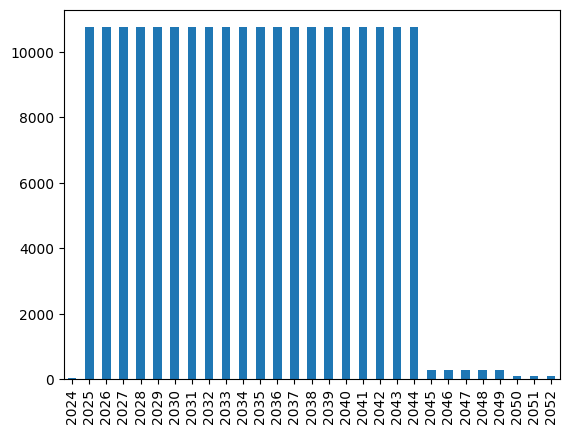

In [11]:
network.statistics.optimal_capacity().div(1e3).sum().plot(kind="bar")

<Axes: xlabel='period,timestep'>

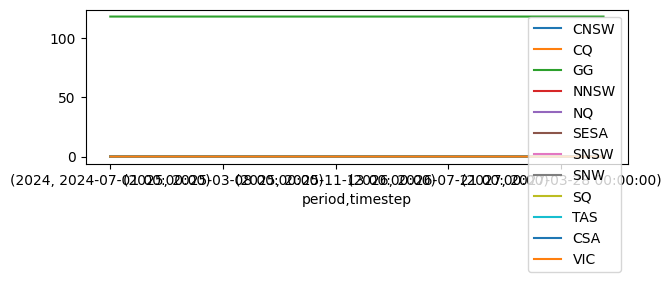

In [27]:
network.buses_t.marginal_price.plot(figsize=(7, 2))

In [30]:
model.variables['Link-p']

Variable (snapshot: 96, Link: 14)
---------------------------------
[2025-01-01 00:00:00, CQ-NQ]: Link-p[2025-01-01 00:00:00, CQ-NQ] ∈ [-inf, inf]
[2025-01-01 00:00:00, CQ-GG]: Link-p[2025-01-01 00:00:00, CQ-GG] ∈ [-inf, inf]
[2025-01-01 00:00:00, SQ-CQ]: Link-p[2025-01-01 00:00:00, SQ-CQ] ∈ [-inf, inf]
[2025-01-01 00:00:00, NNSW-SQ QNI]: Link-p[2025-01-01 00:00:00, NNSW-SQ QNI] ∈ [-inf, inf]
[2025-01-01 00:00:00, NNSW-SQ Terranora]: Link-p[2025-01-01 00:00:00, NNSW-SQ Terranora] ∈ [-inf, inf]
[2025-01-01 00:00:00, CNSW–NNSW QNI]: Link-p[2025-01-01 00:00:00, CNSW–NNSW QNI] ∈ [-inf, inf]
[2025-01-01 00:00:00, CNSW­–SNW North]: Link-p[2025-01-01 00:00:00, CNSW­–SNW North] ∈ [-inf, inf]
		...
[2025-01-02 23:30:00, CNSW–SNW South]: Link-p[2025-01-02 23:30:00, CNSW–SNW South] ∈ [-inf, inf]
[2025-01-02 23:30:00, SNSW–CNSW VNI]: Link-p[2025-01-02 23:30:00, SNSW–CNSW VNI] ∈ [-inf, inf]
[2025-01-02 23:30:00, VIC–SNSW VNI]: Link-p[2025-01-02 23:30:00, VIC–SNSW VNI] ∈ [-inf, inf]
[2025-01-02 23:3

In [7]:
import pypsa 
import pandas as pd

n = pypsa.Network()

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2024-07-01 00:00",
    end="2055-06-30 00:00",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

# convert to multiindex and assign to network
n.snapshots = pd.MultiIndex.from_arrays([snapshots.year, snapshots])
n.investment_periods = years

In [21]:
# apply timeslice mask to capacity and cost
import pandas as pd 

def _get_timeslices(tpath="../Traces/timeslice_RefYear4006.csv",
                    start=(2024,7,1),
                    end  =(2055,6,30)):
    "return type of day for all days in the traces provided"

    # get timeslice df
    df = pd.read_csv(tpath)
    timeslice = {}
    regions = ("NSW","QLD","VIC","TAS","SA")

    day_type_map = {
        "Hot Day" : "SP",
        "Typical Summer" : "ST",
        "Winter" : "W"
    }

    # group timeslices by regions
    for region in regions:
        timeslice[region] = df[df.NAME.str.startswith(region)].copy()

    # create timeslice mask
    for region in regions:

        df = timeslice[region]

        df = df[df["TIMESLICE"]==-1].loc[:]

        # Ensure proper datetime
        df["DATETIME"] = pd.to_datetime(df["DATETIME"], dayfirst=True)

        # Sort by date
        df = df.sort_values("DATETIME").reset_index(drop=True)

        # Add "NEXT" column = next start date
        df["NEXT"] = df["DATETIME"].shift(-1)

        # Type of day compatible with data (ST, SP, or W)
        df["DAY_TYPE"] = df["NAME"].str.split(" ").str[1:].str.join(" ")
        df["DAY_TYPE_SHORT"] = df["DAY_TYPE"].map(day_type_map)

        # Expand each range into daily rows
        blocks = []
        for _, row in df.iterrows():
            start = row["DATETIME"]
            next_date = row["NEXT"]

            # If no next date, just keep the start
            end = start if pd.isna(next_date) else next_date - pd.Timedelta(days=1)

            # Generate daily range
            rng = pd.date_range(start, end, freq="D")
            block = pd.DataFrame({"DATETIME": rng, "DAY_TYPE": row["DAY_TYPE"], "DAY_TYPE_SHORT": row["DAY_TYPE_SHORT"]})
            blocks.append(block)

        out = pd.concat(blocks, ignore_index=True)

        timeslice[region] = out.set_index("DATETIME").sort_index().copy()
    
    return regions,timeslice

def _region_timeslice(region,timeslice):
    "From timeslice for a region get day_type and day_type_short"

    # NAME and DAY_TYPE
    return timeslice[region].copy()

regions,tdf = _get_timeslices()



nsw_ts = _region_timeslice('QLD',tdf)

print(nsw_ts)

# combine days to seasonal ratings and outages

cap = pd.read_csv("../isp_sheets_23/seasonal_ratings/existing_gen_seasonal_ratings.csv")

print(cap)

# snapshots

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2031-07-01 00:00",
    end="2033-07-30 23:30",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

                  DAY_TYPE DAY_TYPE_SHORT
DATETIME                                 
2021-06-30          Winter              W
2021-07-01          Winter              W
2021-07-02          Winter              W
2021-07-03          Winter              W
2021-07-04          Winter              W
...                    ...            ...
2058-03-28  Typical Summer             ST
2058-03-29  Typical Summer             ST
2058-03-30  Typical Summer             ST
2058-03-31  Typical Summer             ST
2058-04-01          Winter              W

[13425 rows x 2 columns]
                  Generator      DUID Region  SP2023-24  SP2024-25  SP2025-26  \
0                 Bayswater      BW01    NSW        630        630        630   
1                 Bayswater      BW02    NSW        655        655        655   
2                 Bayswater      BW03    NSW        655        655        655   
3                 Bayswater      BW04    NSW        655        655        655   
4                 Calli

In [24]:
import pandas as pd

nsw_map = nsw_ts.DAY_TYPE_SHORT.to_dict()

snapshots_day = snapshots.strftime("%Y-%m-%d")

snapshots_day_dt = pd.to_datetime(snapshots_day)
day_types = snapshots_day_dt.map(lambda d: nsw_map.get(d, None))
years = snapshots_day_dt.year
fin_years = years.where(snapshots_day_dt.month < 7, years + 1)

cap_cols = []

for (dt, fy), y in zip(zip(day_types, fin_years),years):
    if dt == 'W':
        if y <= 2032:
            cap_cols.append(f"{dt}{y}")
        else:
            cap_cols.append(f"{dt}2032")
    else:
        if fy <= 2033:
            cap_cols.append(f"{dt}{fy-1}-{str(fy)[-2:]}")
        else:
            cap_cols.append(f"{dt}2032-33")

# # Find the last available column in cap (e.g., 'W2032-33')
# last_col = sorted([col for col in cap.columns if col[-5:] == '32-33'])[-1] if any(col[-5:] == '32-33' for col in cap.columns) else cap.columns[-1]

# Select the row for the desired DUID
cap_row = cap[cap["DUID"] == "KPP_1"].iloc[0]

# Build the capacity list, using last_col if the column is missing
capacity_list = [
    cap_row[col] # if col in cap_row.index else cap_row[last_col]
    for col in cap_cols
]

<Axes: >

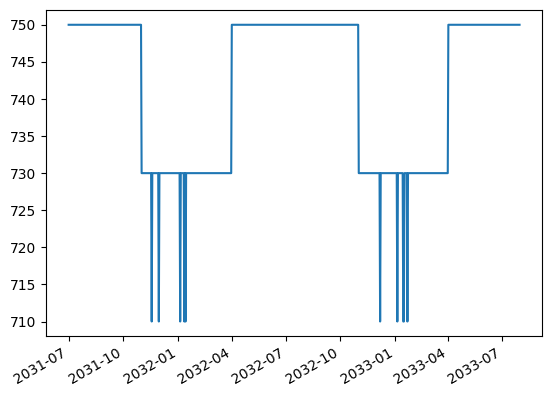

In [25]:
capacity_series = pd.Series(capacity_list, index=snapshots_day_dt)
capacity_series.plot()